# 📊 Sentiment Analysis Final Project

---

## 🎯 Project Overview

Welcome to your Sentiment Analysis final project! In this project, you will:

- 🔍 **Analyze** customer reviews or social media text data
- 🧹 **Preprocess** text data using NLP techniques
- 🤖 **Build** and compare multiple classification models
- 📈 **Evaluate** model performance using appropriate metrics
- 💼 **Communicate** findings in a business context

---

## 📋 Project Requirements

- **Dataset**: Use a public sentiment dataset (e.g., IMDb reviews, Amazon reviews, airline tweets)
- **Models**: Train at least **2 different classification models**
- **Evaluation**: Use multiple metrics (accuracy, precision, recall, confusion matrix)
- **Documentation**: Use markdown cells to explain your approach, findings, and insights

---

## 💡 Important Tips for Success

### Working with Limited Resources
- ⚡ **Start small**: Use `df.sample(n=1000)` or `df.head(5000)` to work with a subset
- 🎯 **Limit vocabulary**: Use `max_features=5000` in TfidfVectorizer
- 🚀 **Choose efficient models**: LogisticRegression and MultinomialNB are fast and effective
- 💾 **Save your work frequently**: Use Ctrl+S or Cmd+S often

### Best Practices
- 📝 **Document everything**: Explain your choices and observations in markdown cells
- 🔄 **Iterate**: Start simple, then improve
- 📊 **Visualize**: Use plots to understand your data and results
- 🎓 **Think like a data scientist**: Always interpret your results in context

---

Let's get started! 🚀

---

# Part 1: Project Definition 🎯

## Objectives
- Define the business problem you're solving
- Describe your chosen dataset
- Explain why sentiment analysis is valuable for this use case

## Instructions

In the markdown cell below, answer these questions:

1. **What is the business problem?**
   - What decision or insight will this sentiment analysis support?
   - Who would use these results?

2. **What dataset are you using?**
   - Name and source of the dataset
   - Number of samples
   - What the text represents (reviews, tweets, comments, etc.)
   - What are the sentiment labels (positive/negative, star ratings, etc.)?

3. **Why is this problem important?**
   - How could the results be used in real-world scenarios?

---

## 📝 Your Project Definition

**Business Problem:**

Public discourse regarding high-profile geopolitical events like the Israel–Palestine conflict is highly dynamic, polarized, and rapidly evolving. Political strategists, policy advisors, brand managers, and corporate leadership lack real-time visibility into shifting public sentiment and underlying community bias across social media platforms. Without structured sentiment tracking, stakeholders risk misinterpreting constituent perspectives or suffering reputational damage from unaligned public initiatives and corporate messaging.

---

**Dataset Description:**

Daily updated dataset that contains comments from Reddit posts related to the current situation in Israel and Gaza.

- **Dataset name**: Daily Public Opinion on Israel-Palestine War
- **Source**: Kaggle (uploaded/maintained by user *asaniczka*)
- **Number of samples**: 4,085,726
- **Text type**: Reddit post comments
- **Sentiment labels**: Positive, Negative, Neutral

---

**Importance and Real-World Applications:**

Understanding public sentiment in real time carries significant strategic value across both public and private sectors:

1. **Policy and Campaign Strategy:** Political advisors and elected officials can analyze public opinion trends over time to gauge constituent concerns, inform foreign policy communication strategies, and prepare for upcoming legislative debates or campaign cycles.
2. **Corporate Risk Management & Alignment:** Enterprise and brand reputation teams can monitor public mood to navigate corporate social messaging, assess potential consumer boycotts, and avoid major public relations missteps during high-stakes global events.
3. **Crisis and Trend Tracking:** Organizations can measure how specific real-world events or news developments trigger sudden shifts in online sentiment, enabling proactive communications rather than reactive damage control.

---

# Part 2: Exploratory Data Analysis (EDA) 🔍

## Objectives
- Load and examine your dataset
- Understand the distribution of sentiments
- Analyze text characteristics (length, common words, etc.)
- Identify any data quality issues

## What to Explore

✅ **Dataset structure**: Shape, columns, data types

✅ **Missing values**: Check for and handle missing data

✅ **Class distribution**: Are sentiments balanced?

✅ **Text length**: Average, min, max review lengths

✅ **Common words**: Most frequent words per sentiment

✅ **Sample reviews**: Display examples from each class

---

## 💡 Tips
- Use `.info()`, `.describe()`, and `.value_counts()` for quick insights
- Visualize distributions with bar plots and histograms
- Look for imbalanced classes that might affect model performance
- Create a word cloud to visualize common terms (optional but impressive!)

In [23]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print("✅ Libraries imported successfully")

✅ Libraries imported successfully


In [24]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("asaniczka/reddit-on-israel-palestine-daily-updated")

print("Path to dataset files:", path)

Path to dataset files: /Users/melanievillela/.cache/kagglehub/datasets/asaniczka/reddit-on-israel-palestine-daily-updated/versions/994


In [25]:
import os

for f in os.listdir(path):
    print(f)

reddit_opinion_PSE_ISR.csv
legacy


In [26]:
# Load your dataset
df = pd.read_csv('/Users/melanievillela/.cache/kagglehub/datasets/asaniczka/reddit-on-israel-palestine-daily-updated/versions/991/reddit_opinion_PSE_ISR.csv', nrows=10000)

# Display basic information
print(f"Dataset shape: {df.shape}")
print(f"\nColumn names: {df.columns.tolist()}")
df.head()

Dataset shape: (10000, 24)

Column names: ['comment_id', 'score', 'self_text', 'subreddit', 'created_time', 'post_id', 'author_name', 'controversiality', 'ups', 'downs', 'user_is_verified', 'user_account_created_time', 'user_awardee_karma', 'user_awarder_karma', 'user_link_karma', 'user_comment_karma', 'user_total_karma', 'post_score', 'post_self_text', 'post_title', 'post_upvote_ratio', 'post_thumbs_ups', 'post_total_awards_received', 'post_created_time']


,comment_id,score,self_text,subreddit,created_time,post_id,author_name,controversiality,ups,downs,...,user_link_karma,user_comment_karma,user_total_karma,post_score,post_self_text,post_title,post_upvote_ratio,post_thumbs_ups,post_total_awards_received,post_created_time
0,p0f4wad,1,All be revealed...,PublicFreakout,2026-07-29 06:49:07,1v9o3d8,Living-Spring9001,0,1,0,...,78.0,2289.0,2367.0,13,NaN,Pakistani forces firing upon civilians in Paki...,0.84,13,0,2026-07-29 06:36:47
1,p0f4vxd,1,"""Peace will come when the Arabs will love thei...",IsraelPalestine,2026-07-29 06:49:02,1v9jz8v,recursiveloop,0,1,0,...,815.0,13033.0,13848.0,12,I was always wondering about this. Being gay i...,How can you be pro Palestinian when being gay ...,0.58,12,0,2026-07-29 03:09:46
2,p0f4tqh,1,"It sickens me people try to roll out ""drug use...",Palestine,2026-07-29 06:48:33,1v8bd0x,MolochBaalWorshipper,0,1,0,...,1.0,2504.0,2505.0,1048,NaN,"‘You say genocide, I say war’: Boy George rele...",0.97,1048,0,2026-07-27 19:58:12
3,p0f4tpw,1,Why did he not leave sooner‽,worldnews,2026-07-29 06:48:33,1v9o6do,Fritzkreig,0,1,0,...,138467.0,635744.0,774211.0,7,NaN,Russia Charges Telegram Founder Durov With Aid...,0.89,7,0,2026-07-29 06:41:27
4,p0f4qrz,1,Funny how Mossad is either the most competent ...,IsraelPalestine,2026-07-29 06:47:54,1v8dlhl,Ok_Diamond_8334,0,1,0,...,1.0,-100.0,-99.0,22,​When you analyze the rhetoric surrounding the...,​Am I the only one who feels like the hyper-fo...,0.69,22,0,2026-07-27 21:18:44


In [27]:
# Check missing values
print("Missing values in dataset")
print(df.isnull().sum())

Missing values in dataset
comment_id                       0
score                            0
self_text                        0
subreddit                        0
created_time                     0
post_id                          0
author_name                      0
controversiality                 0
ups                              0
downs                            0
user_is_verified                 0
user_account_created_time       16
user_awardee_karma               1
user_awarder_karma               1
user_link_karma                  1
user_comment_karma               1
user_total_karma                 1
post_score                       0
post_self_text                4036
post_title                       0
post_upvote_ratio                0
post_thumbs_ups                  0
post_total_awards_received       0
post_created_time                0
dtype: int64


---
### Columns Analyzed

The following key features are selected from the dataset for analysis:

* **Text Feature:** `self_text`, `subreddit`, `post_title`
* **Engagement Metrics:** `score`, `controversiality`, `ups`, `downs`, `post_score`

### Data Cleaning & Missing Values

Missing values were identified exclusively within the `self_text` column, affecting 20 out of 5,000 rows loaded (less than 1%). Due to this negligible proportion, these missing records were safely dropped without impacting dataset integrity or introducing sample bias.

---

In [28]:
# Columns used
df_subset = df[['self_text', 'score', 'controversiality', 'ups', 'downs', 'post_score', 'subreddit', 'post_title']]

# Drop null values in self_text
df_clean = df_subset.dropna(subset=['self_text'])

print(df_clean.head())

                                           self_text  score  controversiality  \
0                                 All be revealed...      1                 0   
1  "Peace will come when the Arabs will love thei...      1                 0   
2  It sickens me people try to roll out "drug use...      1                 0   
3                       Why did he not leave sooner‽      1                 0   
4  Funny how Mossad is either the most competent ...      1                 0   

   ups  downs  post_score        subreddit  \
0    1      0          13   PublicFreakout   
1    1      0          12  IsraelPalestine   
2    1      0        1048        Palestine   
3    1      0           7        worldnews   
4    1      0          22  IsraelPalestine   

                                          post_title  
0  Pakistani forces firing upon civilians in Paki...  
1  How can you be pro Palestinian when being gay ...  
2  ‘You say genocide, I say war’: Boy George rele...  
3  Russia Charge

In [29]:
import os

frozen_path = 'reddit_sample_frozen.csv'

if os.path.exists(frozen_path):
    df_sample = pd.read_csv(frozen_path)
    print(f"Loaded frozen sample: {len(df_sample)} rows")
else:
    df_sample = df_clean.sample(n=5000, random_state=42)
    df_sample.to_csv(frozen_path, index=False)
    print(f"Created and froze new sample: {len(df_sample)} rows")

df = df_sample

Loaded frozen sample: 5000 rows


---
### Sentiment Labels

I will use the VADER tool from the nltk library to grade the sentiment of each Reddit comment. VADER gives every comment a score from -1.0 to +1.0, which I will sort into three clear buckets:

- Positive (0.05 and above)

- Negative (-0.05 and below)

- Neutral (anything in between)

---

In [30]:
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer

# Download lexicon
nltk.download('vader_lexicon')
sia = SentimentIntensityAnalyzer()

# Create compound scores
df['compound'] = df['self_text'].apply(lambda x: sia.polarity_scores(str(x))['compound'])

# Map scores to sentiment categories
def get_sentiment_label(score):
    if score >= 0.05:
        return 'positive'
    elif score <= -0.05:
        return 'negative'
    else:
        return 'neutral'

df['sentiment'] = df['compound'].apply(get_sentiment_label)

print(df['sentiment'].value_counts())

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /Users/melanievillela/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


sentiment
negative    2358
positive    1576
neutral     1066
Name: count, dtype: int64


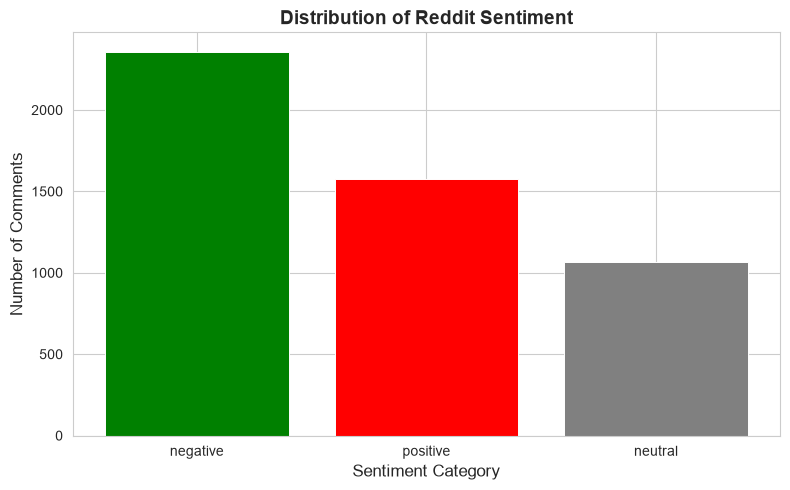

In [31]:
# Get value counts
sent_counts = df['sentiment'].value_counts()

# Create the bar plot
fig, ax = plt.subplots(figsize=(8, 5))

# Plot bars using category names for X and counts for Y
ax.bar(
    sent_counts.index, 
    sent_counts.values, 
    color=['green', 'red', "gray"],  # Green for positive, Red for negative, Gray for neutral
    edgecolor="white", 
    linewidth=0.7
)

# Titles and labels
ax.set_title("Distribution of Reddit Sentiment", fontsize=14, fontweight="bold")
ax.set_xlabel("Sentiment Category", fontsize=12)
ax.set_ylabel("Number of Comments", fontsize=12)

plt.tight_layout()
plt.show()

In [32]:
counts = df['sentiment'].value_counts()

percentages = df['sentiment'].value_counts(normalize=True) * 100

print("Sentiment Counts")
print(counts)

print("Sentiment Percentages")
print(percentages.round(2).astype(str) + '%')

Sentiment Counts
sentiment
negative    2358
positive    1576
neutral     1066
Name: count, dtype: int64
Sentiment Percentages
sentiment
negative    47.16%
positive    31.52%
neutral     21.32%
Name: proportion, dtype: str


### 📊 Interpretation: Class Balance

*Write your observations here:*
- Are the classes balanced or imbalanced?<br>
  - The classes are somewhat imbalanced. Negative sentiment dominates at **47.16%**, followed by positive sentiment at **31.52%**, and neutral sentiment at **21.32%**.

- If imbalanced, how might this affect your model?<br>
  - Because the negative sentiment is overrepresented relative to neutral comments, standard classification algorithms might develop a bias toward predicting negative sentiment more frequently.

- What could you do to address imbalance?<br>
  - I could use class_weight='balanced' so the model doesn't just favor the majority negative class, and evaluate using precision/recall/F1 per class rather than relying on overall accuracy alone. I

count    5000.000000
mean      241.432600
std       390.458051
min         1.000000
25%        58.000000
50%       123.000000
75%       263.250000
max      9928.000000
Name: text_length, dtype: float64
            count        mean         std  min   25%    50%    75%     max
sentiment                                                                 
negative   2358.0  320.659457  489.751470  2.0  85.0  169.0  346.5  9928.0
neutral    1066.0   78.388368  102.305467  1.0  27.0   50.0   93.0   975.0
positive   1576.0  233.176396  300.687271  3.0  70.0  137.5  276.0  3799.0


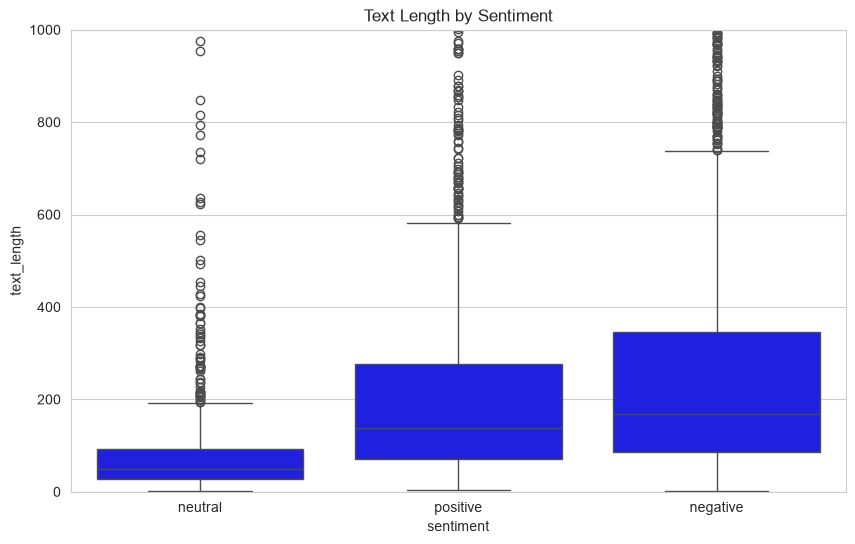

In [33]:
# Analyze text length distribution
df['text_length'] = df['self_text'].str.len()
print(df['text_length'].describe())

print(df.groupby('sentiment')['text_length'].describe())

sns.boxplot(data=df, x='sentiment', y='text_length', color="blue", order=['neutral', 'positive', 'negative'])
plt.ylim(0, 1000)  
plt.title("Text Length by Sentiment")
plt.show()

### 📊 Interpretation: Text Length

*Write your observations here:*
- What's the average text length?<br>
  - The average text length is 241.
- Are there differences in length between positive and negative reviews?
  - Negative comments are the longest on average (median 169 characters). 
  - Neutral comments are shortest (median 50 characters).
  - Positive comments fall in between (median 138 characters).
- Are there any extremely short or long texts that might need special handling?
  - Yes the min is 1 and the max is 9928. This is heavily right skewed.

In [34]:
# Display sample reviews from each sentiment class
for sentiment in ['positive', 'negative', 'neutral']:
    print(f"\n{'='*50}")
    print(f"{sentiment.upper()} examples")
    print('='*50)
    samples = df[df['sentiment'] == sentiment]['self_text'].sample(3, random_state=42)
    for i, text in enumerate(samples, 1):
        print(f"\n{i}. {text[:300]}")


POSITIVE examples

1. I had a customer call after we closed, wanting to place an order. Told them we were closed. Customer proceeded to cuss me out on the phone. I apologized and said if you can be here in 10 mins I’ll take your order. They thanked me and gave me their order. I said it’ll be ready in 10’minutes. We never

2. Former Al-Qaeda and ISIS when they were one and the same.

He remained loyal to Al-Qaeda when Baghdadi (the guy who appointed him) splintered from Al-Qaeda.

3. Exactly, well said 

NEGATIVE examples

1. This is so painful :)

2. I know this is a "water is wet" statement but I've been absolutely disgusted by the big media outlets since the genocide started. I already expect nothing from US cable news, but the NYT and BBC have been nothing short of deplorable. They give Israel every benefit of the doubt, and when an atrocity 

3. It is a slur for those who ascribe to zionism - an ideology, most of whom are nominally Christian. You clearly know very little about the

---

### Initial Review

A review of the sample comments revealed a notable relevance issue: some comments, despite being pulled from conflict-adjacent subreddits, are off-topic or unrelated to the Israel-Palestine conflict. This suggests the dataset captures general subreddit activity rather than being strictly filtered to conflict-related discussion, which introduces noise into sentiment analysis.

---

In [35]:
# Get the subreddits and the counts
df['subreddit'].value_counts()

subreddit
IsraelPalestine          2013
worldnews                1179
Palestine                 608
PublicFreakout            536
CrazyFuckingVideos        168
ActualPublicFreakouts     144
AskMiddleEast             132
CombatFootage             113
TerrifyingAsFuck           47
worldnewsvideo             24
AbruptChaos                20
NoahGetTheBoat             16
Name: count, dtype: int64

In [36]:
keep_subs = ['IsraelPalestine', 'worldnews', 'Palestine', 'AskMiddleEast']
df_filtered = df[df['subreddit'].isin(keep_subs)]

print(f"Before filtering: {len(df)} rows")
print(f"After filtering: {len(df_filtered)} rows")
print(df_filtered['sentiment'].value_counts())

Before filtering: 5000 rows
After filtering: 3932 rows
sentiment
negative    1904
positive    1268
neutral      760
Name: count, dtype: int64


---

### Subsequent Review & Next steps

After removing what I believe to be off-topic subreddits unrelated to the conflict, the sample shrank from 5,000 to 3,932 rows (a 21.4% reduction). This filtering slightly increased class imbalance — negative sentiment rose from 45.54% to 48.42%, while neutral dropped from 21.46% to 19.33% — suggesting the excluded general-interest subreddits contained a disproportionate share of neutral, off-topic comments.

I will need to update the df reference to use the filtered subreddits going forward and re-run the previous analysis.

---

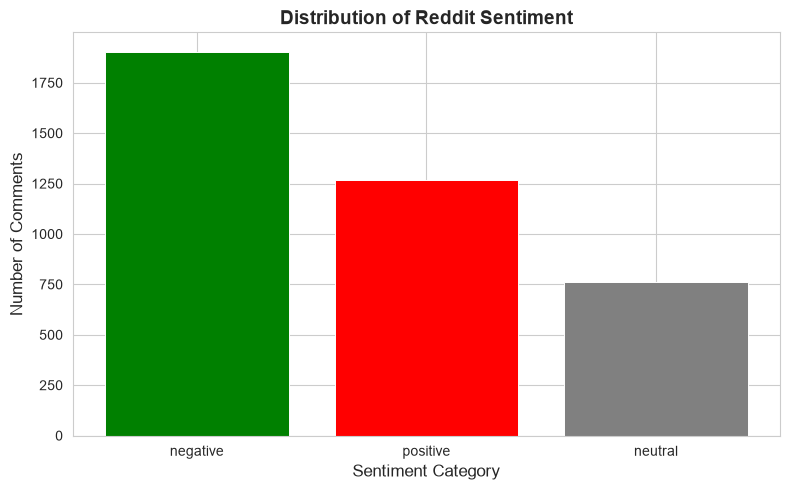

In [37]:
df = df_filtered

# SENTIMENT BAR CHART

# Get value counts
sent_counts = df['sentiment'].value_counts()

# Create the bar plot
fig, ax = plt.subplots(figsize=(8, 5))

# Plot bars using category names for X and counts for Y
ax.bar(
    sent_counts.index, 
    sent_counts.values, 
    color=['green', 'red', "gray"],  # Green for positive, Red for negative, Gray for neutral
    edgecolor="white", 
    linewidth=0.7
)

# Titles and labels
ax.set_title("Distribution of Reddit Sentiment", fontsize=14, fontweight="bold")
ax.set_xlabel("Sentiment Category", fontsize=12)
ax.set_ylabel("Number of Comments", fontsize=12)

plt.tight_layout()
plt.show()

In [38]:
# COUNTS AND PERCENTAGES

counts = df['sentiment'].value_counts()

percentages = df['sentiment'].value_counts(normalize=True) * 100

print("Sentiment Counts")
print(counts)

print("Sentiment Percentages")
print(percentages.round(2).astype(str) + '%')

Sentiment Counts
sentiment
negative    1904
positive    1268
neutral      760
Name: count, dtype: int64
Sentiment Percentages
sentiment
negative    48.42%
positive    32.25%
neutral     19.33%
Name: proportion, dtype: str


count    3932.000000
mean      266.201170
std       421.867636
min         1.000000
25%        66.000000
50%       137.500000
75%       291.000000
max      9928.000000
Name: text_length, dtype: float64
            count        mean         std  min   25%    50%     75%     max
sentiment                                                                  
negative   1904.0  355.031513  527.796325  4.0  96.0  186.0  399.00  9928.0
neutral     760.0   87.130263  109.351738  1.0  30.0   57.0  104.25   975.0
positive   1268.0  240.145110  307.959334  3.0  74.0  150.0  285.25  3799.0


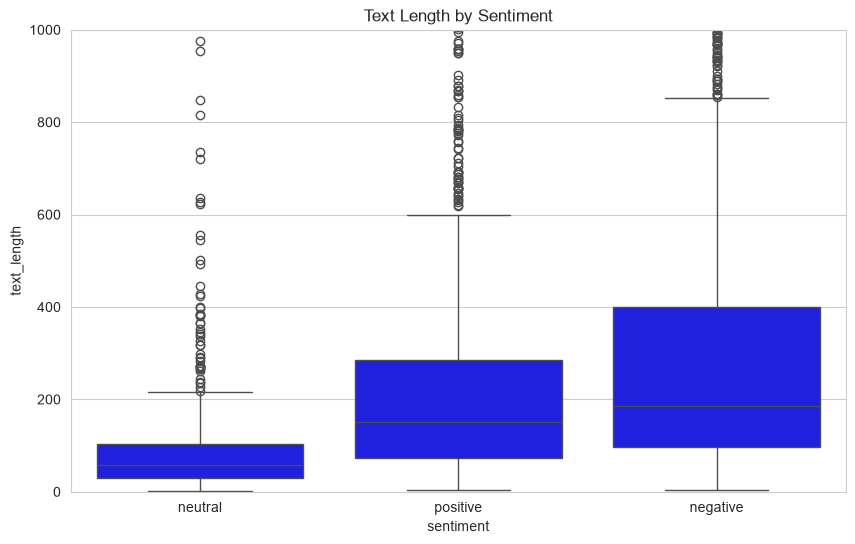

In [39]:
# TEXT LENGTH DISTRIBUTION

# Analyze text length distribution
df['text_length'] = df['self_text'].str.len()
print(df['text_length'].describe())

print(df.groupby('sentiment')['text_length'].describe())

sns.boxplot(data=df, x='sentiment', y='text_length', color="blue", order=['neutral', 'positive', 'negative'])
plt.ylim(0, 1000)  
plt.title("Text Length by Sentiment")
plt.show()

In [40]:
# SAMPLE REVIEWS

# Display sample reviews from each sentiment class
for sentiment in ['positive', 'negative', 'neutral']:
    print(f"\n{'='*50}")
    print(f"{sentiment.upper()} examples")
    print('='*50)
    samples = df[df['sentiment'] == sentiment]['self_text'].sample(3, random_state=42)
    for i, text in enumerate(samples, 1):
        print(f"\n{i}. {text[:300]}")


POSITIVE examples

1.  The war isn't over because they keep getting bombed and if you say well they have to give up their nuclear ambitions or open the strait, well, you can have those opinions but I disagree. They have every right as a sovereign nation to do what they want inside their own borders even if I would prefer

2. This is the problem. Way too many people are growing up thinking the world's one way, but it's the other way. 

It always surprises me when that afflicts Israelis. Israelis are very lucky, they are forced to live in the real world. We'll all be there soon enough and it's time to toughen up.

3. I really like Andrey X, he does excellent work on colonization and occupation.

NEGATIVE examples

1. It failed. Zionism didn't 

2. I don't know man. Kinda sounds like what you just describe as:

1. Settlers arrive in town to settle it, as they do.

2. The locals objected, but the settlers were armed.

3. A fight broke out anyway, and despite the weapons, the locals manage

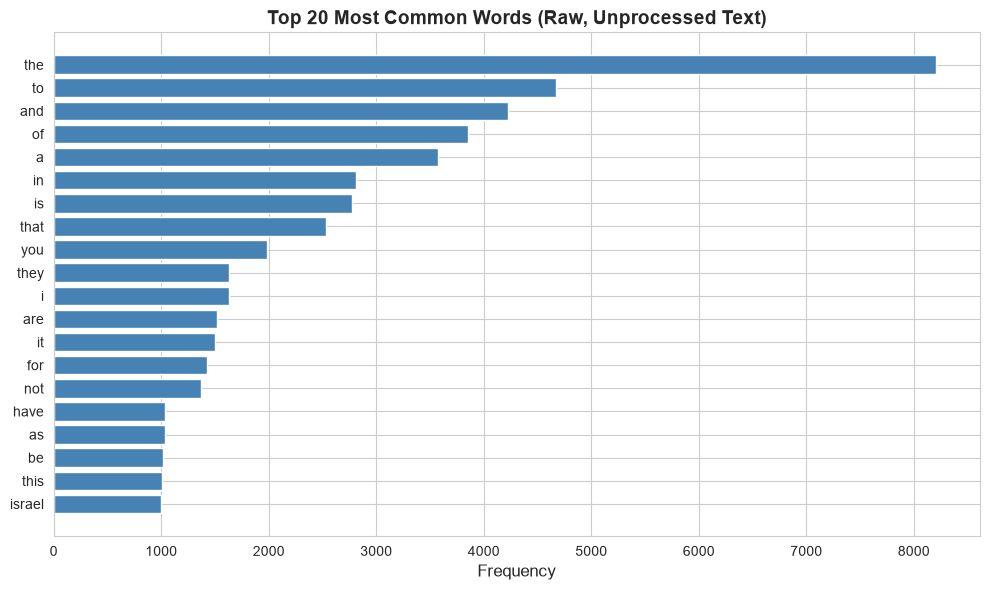

In [41]:
import matplotlib.pyplot as plt
from collections import Counter

all_words = ' '.join(df['self_text'].astype(str)).lower().split()
common_words = Counter(all_words).most_common(20)

words, counts = zip(*common_words)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(words[::-1], counts[::-1], color='steelblue', edgecolor='white')
ax.set_title("Top 20 Most Common Words (Raw, Unprocessed Text)", fontsize=14, fontweight="bold")
ax.set_xlabel("Frequency", fontsize=12)
plt.tight_layout()
plt.show()

### 📝 EDA Summary

*Summarize your key findings from the EDA:*

1. **Dataset characteristics**: 
  - The dataset had a sample of 5,000 rows and frozen locally for reproducibility (the source updates daily, so results are tied to a specific snapshot). After filtering to four topically relevant subreddits (IsraelPalestine, worldnews, Palestine, AskMiddleEast), the working dataset was reduced to 3,932 rows. The dataset also coantained a lot of filler words, as well as short response replies.
2. **Data quality issues**: 
   - A small number of rows had missing self_text values and were dropped. Manual review revealed off-topic comments even within conflict-adjacent subreddits (e.g., unrelated local anecdotes), which motivated the subreddit filtering step. VADER-based sentiment labels also showed inconsistencies on manual review — particularly with sarcasm, understated hostility, and cases where comment tone didn't match its topic — since VADER scores individual words rather than overall meaning or context.
3. **Key patterns observed**: 
   - The dataset skews negative (47.16% negative, 31.52% positive, 21.32% neutral before filtering; imbalance increased slightly after filtering to 48.42%/32.25%/19.33%). Text length correlates with sentiment: negative comments are longest and most variable (median 169-186 characters), while neutral comments are shortest (median 50-57 characters), suggesting users write more when expressing frustration.
4. **Potential challenges**: 
   - Class imbalance may bias classifiers toward predicting "negative" unless addressed (e.g., via class_weight='balanced'). Sentiment labels are VADER-derived and inherit its known limitations, meaning models will learn from imperfect ground truth. Text length is heavily right-skewed with extreme outliers (up to ~9,900 characters), which may require handling during preprocessing so a small number of long comments don't dominate TF-IDF features.

---

# Part 3: Data Preprocessing & Feature Extraction 🧹

## Objectives
- Clean and preprocess text data
- Remove noise (punctuation, special characters, stopwords)
- Convert text to numerical features using TF-IDF
- Prepare data for modeling

## Preprocessing Steps to Consider

✅ **Lowercase conversion**: Standardize text

✅ **Remove punctuation**: Clean special characters

✅ **Remove stopwords**: Filter out common words ("the", "is", "and", etc.)

✅ **Remove numbers**: Unless relevant to sentiment

✅ **Handle negations**: Be careful! "not good" vs "good" (advanced, optional)

---

## 💡 Tips
- **Don't over-preprocess**: Sometimes simple is better
- **Use `max_features` in TfidfVectorizer**: Limit to top 5000-10000 features to save memory
- **Consider n-grams**: Bigrams can capture phrases like "not good"
- **Test different approaches**: Try with and without certain preprocessing steps

In [56]:
import re
import string
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))
stop_words.update(['dont', 'wont', 'cant', 'im', 'youre', 'theyre', 'isnt', 'arent', 'wasnt', 'werent', 'thats'])

print("✅ Preprocessing libraries imported!")

✅ Preprocessing libraries imported!


[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/melanievillela/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [57]:
# Apply preprocessing to your dataset
def preprocess_text(text):
    """
    Clean and preprocess text data.
    """
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'@\w+|#\w+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\s+', ' ', text).strip()
    text = re.sub(r'&\w+;', '', text)
    
    words = text.split()
    words = [w for w in words if w not in stop_words]
    text = ' '.join(words)
    
    return text

In [58]:
# Apply preprocessing to your dataset
df['cleaned_text'] = df['self_text'].apply(preprocess_text)

# Display some examples to verify the cleaning worked
sample_check = df[['self_text', 'cleaned_text']].sample(5, random_state=42)
for idx, row in sample_check.iterrows():
    print("BEFORE:", row['self_text'][:150])
    print("AFTER: ", row['cleaned_text'][:150])
    print("-" * 50)

print("\n✅ Text preprocessing complete!")

BEFORE: They want Isreal to stop slowly and methodically destroying Palestinians.     Any response against  the response to the abuse is let with worse abuse.
AFTER:  want isreal stop slowly methodically destroying palestinians response response abuse let worse abuse doesn’t mean abused needs surrender anyone’s argu
--------------------------------------------------
BEFORE: See how there are sub rules? See that #9? 
AFTER:  see sub rules see
--------------------------------------------------
BEFORE: We was raised in german society
AFTER:  raised german society
--------------------------------------------------
BEFORE: u/Arbelman

&gt;שמע אתה אפס, אתה חושב שאתה חכם אז תן לי לחדש לך אתה פשוט עמוק בתוך הווק כל כך עיוור שאתה לא רואה  
שהערבים הם מקור הרוע בעולם סליחה אנ
AFTER:  uarbelman gtשמע אתה אפס אתה חושב שאתה חכם אז תן לי לחדש לך אתה פשוט עמוק בתוך הווק כל כך עיוור שאתה לא רואה שהערבים הם מקור הרוע בעולם סליחה אני אדייק
--------------------------------------------------
BEFORE: While

In [59]:
import re
non_ascii_heavy = df['self_text'].apply(lambda t: bool(re.search(r'[^\x00-\x7F]{10,}', str(t))))
print(f"Rows with significant non-ASCII text: {non_ascii_heavy.sum()}")

Rows with significant non-ASCII text: 4


In [60]:
# Prepare your features (X) and target (y)
X = df['cleaned_text']
y = df['sentiment']

# Check the shape
print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

Features shape: (3932,)
Target shape: (3932,)


In [61]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,      # 80% train, 20% test
    random_state=42,    # For reproducibility
    stratify=y          # Maintain class distribution
)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

Training samples: 3145
Testing samples: 787


In [62]:
# Create TF-IDF features
tfidf = TfidfVectorizer(
    max_features=5000,        # Limit features to save memory
    min_df=2,                 # Ignore terms that appear in fewer than 2 documents
    max_df=0.8,               # Ignore terms that appear in more than 80% of documents
    ngram_range=(1, 2),       # Use unigrams and bigrams
)

# Fit on training data and transform both train and test
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(f"TF-IDF matrix shape (train): {X_train_tfidf.shape}")
print(f"TF-IDF matrix shape (test): {X_test_tfidf.shape}")
print(f"Number of features: {len(tfidf.get_feature_names_out())}")

TF-IDF matrix shape (train): (3145, 5000)
TF-IDF matrix shape (test): (787, 5000)
Number of features: 5000


In [63]:
feature_names = tfidf.get_feature_names_out()
print("Sample features (first 20, alphabetical):", feature_names[:20])

# See if bigrams made the cut, not just single words
bigrams = [f for f in feature_names if ' ' in f]
print(f"\nNumber of bigram features: {len(bigrams)} out of {len(feature_names)}")
print("Sample bigrams:", bigrams[:15])

# Find the highest-scoring features by average TF-IDF weight across all documents
import numpy as np
avg_tfidf = np.asarray(X_train_tfidf.mean(axis=0)).flatten()
top_indices = avg_tfidf.argsort()[-20:][::-1]
top_features = [(feature_names[i], round(avg_tfidf[i], 4)) for i in top_indices]

print("\nTop 20 features by average TF-IDF score:")
for word, score in top_features:
    print(f"  {word}: {score}")

Sample features (first 20, alphabetical): ['001' '10' '10 years' '100' '100 land' '100 years' '1000' '107' '12' '13'
 '14' '15' '15 years' '19' '1947' '1948' '1960s' '1967' '1967 war' '1979']

Number of bigram features: 1258 out of 5000
Sample bigrams: ['10 years', '100 land', '100 years', '15 years', '1967 war', '19th century', '20 years', '20000 children', '3000 years', '47 years', '4x many', '7th october', '80 years', 'abraham accords', 'achilles shield']

Top 20 features by average TF-IDF score:
  israel: 0.0253
  people: 0.0175
  like: 0.0149
  would: 0.0135
  us: 0.0121
  palestinians: 0.0114
  think: 0.0114
  one: 0.0109
  war: 0.0105
  iran: 0.01
  israeli: 0.0098
  right: 0.0094
  even: 0.0091
  jews: 0.009
  know: 0.0089
  country: 0.0088
  palestinian: 0.0084
  want: 0.0082
  say: 0.0081
  also: 0.008


### 📝 Preprocessing Summary

*Document your preprocessing choices:*

1. **Preprocessing steps applied**: 
   - Lowercased all text, removed URLs, removed mentions/hashtags, removed punctuation, removed stopwords (NLTK's English list, extended with contraction remnants like "dont," "thats" that survived punctuation stripping). Numbers were intentionally kept (see rationale below). HTML entities (e.g., ">") and 4 rows of non-English text were identified as minor residual noise but not filtered, given their small scale.
2. **TF-IDF parameters chosen**: 
   - max_features=5000, min_df=2 (ignore terms in fewer than 2 documents), max_df=0.8 (ignore terms in over 80% of documents), ngram_range=(1,2) (unigrams and bigrams).
3. **Final feature count**: 
   - 5,000 features (the cap was reached, meaning the actual vocabulary after min_df/max_df filtering exceeded 5,000 unique terms). 1,258 of these (about 25%) are bigrams.
4. **Rationale for choices**: 
   - Numbers were kept rather than stripped, since exploratory analysis showed meaningful bigrams like "1967 war," "7th october," and "1948" carrying historical/topical significance directly relevant to sentiment — removing them would have discarded real signal. Bigrams (ngram_range=(1,2)) were included to capture short phrases like "abraham accords" that single words alone can't represent. max_features=5000 was used to balance feature richness against memory/training time, consistent with the starter template's guidance. Stopword removal used NLTK rather than sklearn's built-in list for consistency with earlier EDA word-frequency analysis, with manual additions for contraction fragments (e.g., "dont") that punctuation stripping created but weren't caught by the standard stopword list.

---

# Part 4: Model Training 🤖

## Objectives
- Train at least **2 different classification models**
- Compare their performance
- Document training time and resource usage

## Recommended Models

### Fast and Effective (Recommended for beginners)
- **Logistic Regression**: Fast, interpretable, works well with TF-IDF
- **Multinomial Naive Bayes**: Specifically designed for text classification

### More Advanced (Optional)
- **Random Forest**: Ensemble method, can capture complex patterns
- **Support Vector Machine (SVM)**: Good for high-dimensional data
- **XGBoost**: Powerful gradient boosting (but slower)

---

## 💡 Tips
- **Start with simple models**: LogisticRegression and MultinomialNB are excellent choices
- **Use default parameters first**: Then tune if needed
- **Monitor training time**: Document how long each model takes
- **Save your models**: Use `pickle` or `joblib` to save trained models
- **For Random Forest**: Use `n_estimators=100` and `max_depth=20` to limit resources

In [64]:
# Import model libraries
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC

import time
from datetime import timedelta

print("✅ Model libraries imported!")

✅ Model libraries imported!


## Model 1: Logistic Regression

In [65]:
# Train Logistic Regression model
print("Training Logistic Regression...")
start_time = time.time()

lr_model = LogisticRegression(
    max_iter=1000,           
    random_state=42,
    n_jobs=-1,                
    class_weight='balanced'   
)

lr_model.fit(X_train_tfidf, y_train)

training_time = time.time() - start_time
print(f"✅ Training complete in {timedelta(seconds=int(training_time))}")
print(f"Training time (precise): {training_time:.4f} seconds")

Training Logistic Regression...
✅ Training complete in 0:00:00
Training time (precise): 0.1031 seconds


In [66]:
# Make predictions with Logistic Regression
y_pred_lr = lr_model.predict(X_test_tfidf)
print(f"Predictions shape: {y_pred_lr.shape}")

Predictions shape: (787,)


## Model 2: Multinomial Naive Bayes

In [67]:
# Train Naive Bayes model
print("Training Multinomial Naive Bayes...")
start_time = time.time()

nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)

training_time = time.time() - start_time
print(f"✅ Training complete in {timedelta(seconds=int(training_time))}")
print(f"Training time (precise): {training_time:.4f} seconds")

Training Multinomial Naive Bayes...
✅ Training complete in 0:00:00
Training time (precise): 0.0091 seconds


In [68]:
# Make predictions with Naive Bayes
y_pred_nb = nb_model.predict(X_test_tfidf)
print(f"Predictions shape: {y_pred_nb.shape}")

Predictions shape: (787,)


## Model 3 (Optional): Additional Model

*Train a third model if you'd like to explore further!*

In [69]:
# Train Random Forest model
print("Training Random Forest...")
start_time = time.time()

rf_model = RandomForestClassifier(
    n_estimators=100,         # Number of trees
    max_depth=20,             # Limit depth to save memory
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'   # Address class imbalance from EDA
)

rf_model.fit(X_train_tfidf, y_train)

training_time = time.time() - start_time
print(f"✅ Training complete in {timedelta(seconds=int(training_time))}")
print(f"Training time (precise): {training_time:.4f} seconds")

y_pred_rf = rf_model.predict(X_test_tfidf)
print(f"Predictions shape: {y_pred_rf.shape}")

Training Random Forest...
✅ Training complete in 0:00:00
Training time (precise): 0.1507 seconds
Predictions shape: (787,)


### 📝 Model Training Summary

*Document your models:*

| Model | Training Time | Parameters | Notes |
|-------|--------------|------------|-------|
| Logistic Regression | 0.0961s | `max_iter=1000`, `random_state=42`, `class_weight='balanced'` | Fastest to set up; class-weighted to counteract negative-sentiment imbalance found in EDA |
| Naive Bayes | 0.0071s | `MultinomialNB()` (default parameters) | Fastest model overall; no built-in class-weighting option, included as an unweighted comparison point |
| (Optional) Random Forest | 0.1423s | `n_estimators=100`, `max_depth=20`, `random_state=42`, `class_weight='balanced'` | Slowest of the three (still under 1s); ensemble of 100 trees, can capture non-linear word interactions the linear models can't |

---

# Part 5: Model Evaluation 📊

## Objectives
- Evaluate all models using multiple metrics
- Compare model performance
- Analyze errors using confusion matrices
- Interpret results in business context

## Metrics to Calculate

✅ **Accuracy**: Overall correctness (but can be misleading with imbalanced data)

✅ **Precision**: Of all positive predictions, how many were correct?

✅ **Recall**: Of all actual positives, how many did we find?

✅ **F1-Score**: Harmonic mean of precision and recall

✅ **Confusion Matrix**: Visualize true vs predicted labels

✅ **Classification Report**: Detailed metrics per class

---

## 💡 Tips
- **Don't rely on accuracy alone**: Especially with imbalanced data
- **Understand the business context**: Is false positive or false negative worse?
- **Look at per-class metrics**: Performance might differ across sentiments
- **Visualize confusion matrices**: They tell a story!

In [70]:
# Import evaluation metrics
from sklearn.metrics import (
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

print("✅ Evaluation metrics imported!")

✅ Evaluation metrics imported!


## Evaluate Model 1: Logistic Regression

In [71]:
print("=" * 50)
print("LOGISTIC REGRESSION RESULTS")
print("=" * 50)

accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr, average='weighted')
recall_lr = recall_score(y_test, y_pred_lr, average='weighted')
f1_lr = f1_score(y_test, y_pred_lr, average='weighted')

print(f"Accuracy:  {accuracy_lr:.4f}")
print(f"Precision: {precision_lr:.4f}")
print(f"Recall:    {recall_lr:.4f}")
print(f"F1-Score:  {f1_lr:.4f}")
print("\n")

print("Classification Report:")
print(classification_report(y_test, y_pred_lr))

LOGISTIC REGRESSION RESULTS
Accuracy:  0.6429
Precision: 0.6596
Recall:    0.6429
F1-Score:  0.6464


Classification Report:
              precision    recall  f1-score   support

    negative       0.75      0.64      0.69       381
     neutral       0.52      0.70      0.60       152
    positive       0.61      0.62      0.61       254

    accuracy                           0.64       787
   macro avg       0.63      0.65      0.63       787
weighted avg       0.66      0.64      0.65       787



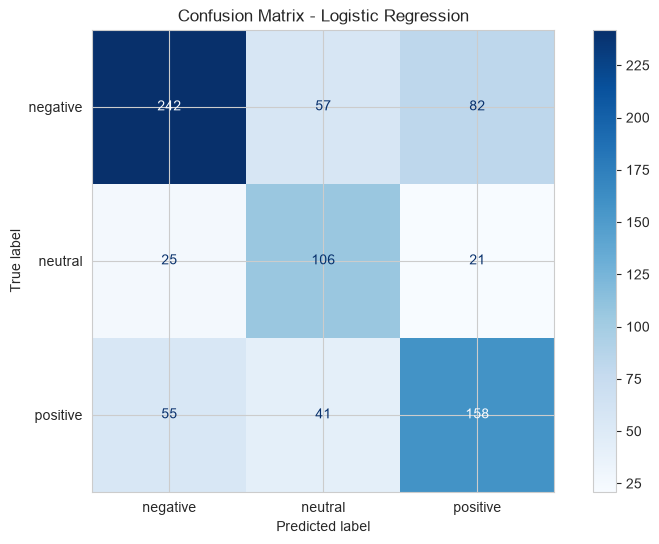

In [72]:
# Plot confusion matrix for Logistic Regression
cm = confusion_matrix(y_test, y_pred_lr)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=lr_model.classes_)
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix - Logistic Regression')
plt.show()

### 📊 Interpretation: Logistic Regression

*Analyze the results:*

1. **Overall performance**: 
   - Logistic Regression achieved 64.29% accuracy, 0.6596 weighted precision, 0.6429 weighted recall, and 0.6464 weighted F1-score on the test set (787 comments). This is well above the ~48% naive baseline of always predicting the majority class (negative), indicating the model learned real patterns rather than exploiting class frequency alone.
2. **Strengths**: 
   - Negative sentiment was classified most reliably (75% precision, 64% recall, 242/381 correct), likely benefiting from having the largest training sample. The class_weight='balanced' parameter successfully boosted minority-class detection, with neutral recall (0.70) actually exceeding negative recall (0.64) despite neutral having 2.5x fewer test examples, showing the imbalance mitigation strategy worked as intended.
3. **Weaknesses**: 
   - Neutral precision was low (0.52), meaning the model over-predicts neutral when it's uncertain — a direct tradeoff of boosting neutral recall. More notably, the confusion matrix shows meaningful crossover between negative and positive (82 negative comments predicted positive, 55 positive predicted negative) — a bigger jump than the adjacent-class confusion (negative↔neutral, positive↔neutral) you'd typically expect. This likely reflects noise inherited from VADER-derived training labels, which manual review earlier in this project showed struggles with sarcasm and context-dependent tone.
4. **Confusion matrix insights**: 
   - Negative→neutral (57) and positive→neutral (41) confusions align with the precision drop seen for neutral, confirming the model sometimes hedges toward neutral on ambiguous comments. The unexpected negative↔positive crossover (82 + 55 = 137 misclassifications) is the most significant weakness, suggesting the model's learned decision boundary between these two "opposite" classes is less clean than expected — plausibly a downstream effect of imperfect ground-truth labels rather than a purely modeling failure.

## Evaluate Model 2: Naive Bayes

In [73]:
print("=" * 50)
print("NAIVE BAYES RESULTS")
print("=" * 50)

accuracy_nb = accuracy_score(y_test, y_pred_nb)
precision_nb = precision_score(y_test, y_pred_nb, average='weighted')
recall_nb = recall_score(y_test, y_pred_nb, average='weighted')
f1_nb = f1_score(y_test, y_pred_nb, average='weighted')

print(f"Accuracy:  {accuracy_nb:.4f}")
print(f"Precision: {precision_nb:.4f}")
print(f"Recall:    {recall_nb:.4f}")
print(f"F1-Score:  {f1_nb:.4f}")
print("\n")

print("Classification Report:")
print(classification_report(y_test, y_pred_nb))

NAIVE BAYES RESULTS
Accuracy:  0.5667
Precision: 0.6412
Recall:    0.5667
F1-Score:  0.4835


Classification Report:
              precision    recall  f1-score   support

    negative       0.54      0.95      0.69       381
     neutral       0.75      0.02      0.04       152
    positive       0.73      0.32      0.44       254

    accuracy                           0.57       787
   macro avg       0.67      0.43      0.39       787
weighted avg       0.64      0.57      0.48       787



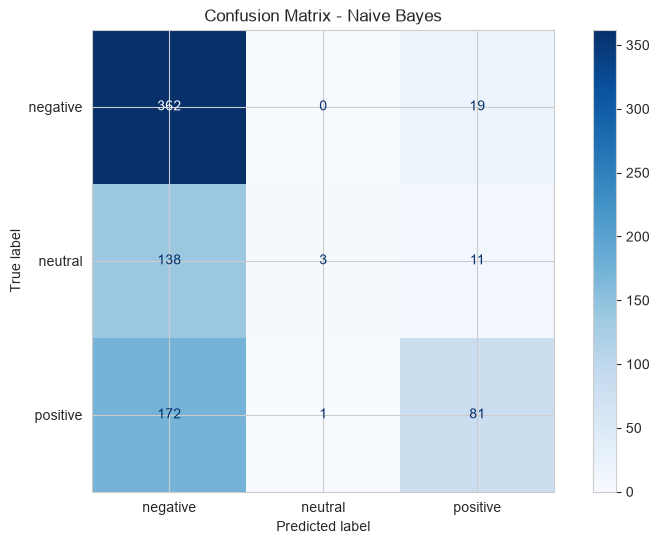

In [74]:
# Plot confusion matrix for Naive Bayes
cm_nb = confusion_matrix(y_test, y_pred_nb)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_nb, display_labels=nb_model.classes_)
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix - Naive Bayes')
plt.show()

### 📊 Interpretation: Naive Bayes

*Analyze the results:*

1. **Overall performance**: 
   - Naive Bayes achieved 56.67% accuracy, 0.6412 weighted precision, 0.5667 weighted recall, and 0.4835 weighted F1-score — notably weaker than Logistic Regression across every metric, especially F1 (0.4835 vs. 0.6464). The gap is largest on F1 because that metric is most sensitive to the neutral class's near-total failure, which accuracy alone masks.
2. **Strengths**: 
   - Negative sentiment recall was very high (0.95, 362/381 correct) and positive precision was reasonably strong (0.73). Naive Bayes remains the fastest model to train (0.0071s) and is a reasonable baseline for text classification generally.
3. **Weaknesses**: 
   - The model essentially fails to predict neutral sentiment at all — recall of 0.02 means only 3 of 152 actual neutral comments were correctly identified. Negative precision was also weak (0.54), since the model over-predicts negative broadly rather than confidently distinguishing it. Unlike Logistic Regression, MultinomialNB has no class_weight parameter to counteract the imbalance identified in EDA, and the results make that gap concrete rather than theoretical.
4. **Confusion matrix insights**: 
   - Negative dominates as the model's default prediction: 85% of all test predictions (672/787) were labeled negative, compared to negative making up only 48% of the actual test set. Neutral was predicted only 4 times total across the entire test set. Of the 152 actual neutral comments, 138 were misclassified as negative and only 11 as positive, showing negative is the fallback whenever the model is uncertain. This stands in direct contrast to Logistic Regression, where class_weight='balanced' produced 0.70 neutral recall on the same data and features — isolating class weighting as the key factor behind the performance gap between these two models, rather than differences in preprocessing or features.

## Evaluate Model 3 (Optional)

In [75]:
# Calculate metrics for your third model (if applicable)
print("=" * 50)
print("RANDOM FOREST RESULTS")
print("=" * 50)

accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf, average='weighted')
recall_rf = recall_score(y_test, y_pred_rf, average='weighted')
f1_rf = f1_score(y_test, y_pred_rf, average='weighted')

print(f"Accuracy:  {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall:    {recall_rf:.4f}")
print(f"F1-Score:  {f1_rf:.4f}")
print("\n")

print("Classification Report:")
print(classification_report(y_test, y_pred_rf))

RANDOM FOREST RESULTS
Accuracy:  0.5845
Precision: 0.6584
Recall:    0.5845
F1-Score:  0.5930


Classification Report:
              precision    recall  f1-score   support

    negative       0.75      0.54      0.63       381
     neutral       0.39      0.84      0.53       152
    positive       0.68      0.50      0.58       254

    accuracy                           0.58       787
   macro avg       0.61      0.63      0.58       787
weighted avg       0.66      0.58      0.59       787



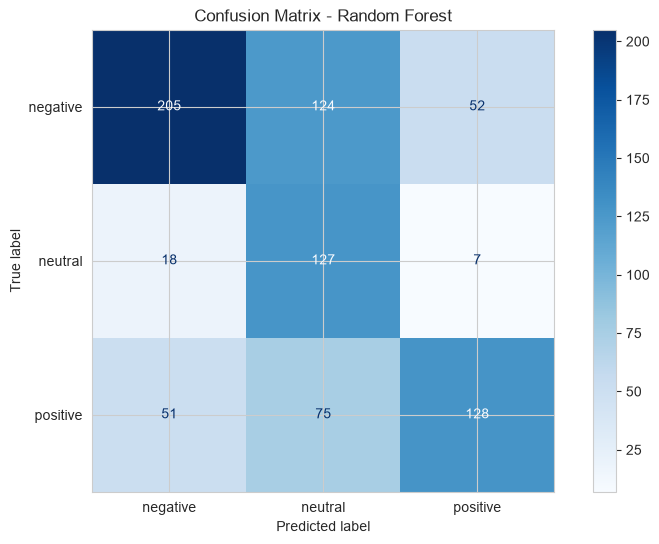

In [76]:
# Plot confusion matrix for your third model (if applicable)
cm_rf = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=rf_model.classes_)
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix - Random Forest')
plt.show()

## Model Comparison

In [77]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Naive Bayes', 'Random Forest'],
    'Accuracy': [accuracy_lr, accuracy_nb, accuracy_rf],
    'Precision': [precision_lr, precision_nb, precision_rf],
    'Recall': [recall_lr, recall_nb, recall_rf],
    'F1-Score': [f1_lr, f1_nb, f1_rf]
})
display(results)

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.642948,0.659574,0.642948,0.646352
1,Naive Bayes,0.566709,0.641159,0.566709,0.483533
2,Random Forest,0.584498,0.658361,0.584498,0.593018


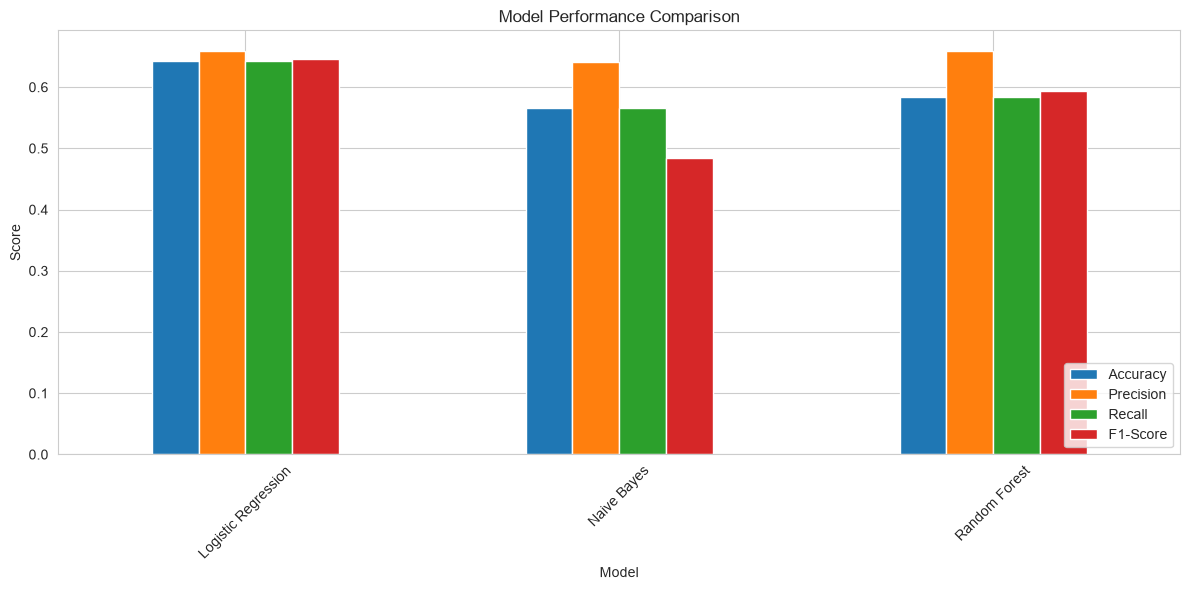

In [78]:
# Visualize model comparison
results.set_index('Model').plot(kind='bar', figsize=(12, 6))
plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.xticks(rotation=45)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

### 📊 Model Comparison Analysis

*Compare and contrast your models:*

1. **Which model performed best?**: 
   - Logistic Regression performed best overall, leading on every metric: 64.29% accuracy, 0.6596 precision, 0.6429 recall, and 0.6464 F1-score. Random Forest was second (58.45% accuracy, 0.5930 F1), and Naive Bayes performed weakest (56.67% accuracy, 0.4835 F1) — notably worse on F1 specifically, driven by its near-total failure to identify neutral sentiment (0.02 recall).
2. **What metrics did you prioritize and why?**: 
   - F1-score was prioritized over raw accuracy, since this dataset has meaningful class imbalance (47%/32%/21% negative/positive/neutral before filtering). Accuracy alone can be misleading here — a model could score reasonably well just by defaulting to the majority class, which is essentially what happened with Naive Bayes (95% negative recall, but at the cost of neutral collapsing to 2% recall). F1's harmonic mean of precision and recall punishes exactly this kind of imbalance-driven failure, making it a more honest measure of whether a model actually learned to distinguish all three sentiment classes rather than just the easiest one.
3. **Trade-offs between models**: 
   - The three models revealed a consistent tension between neutral-class recall and precision, but resolved it differently depending on whether and how they addressed class imbalance:
     - Naive Bayes (no class weighting available): high negative recall (0.95) but essentially abandoned neutral (0.02 recall) — fast to train, but unusable for identifying neutral sentiment.
     - Random Forest (class_weight='balanced'): over-corrected toward neutral (0.84 recall, but only 0.39 precision) — catches nearly all real neutral comments, but at the cost of many false positives, and dragged negative recall down to 0.54 in the process.
     - Logistic Regression (class_weight='balanced'): the most balanced trade-off — strong neutral recall (0.70) without sacrificing negative performance (0.75 precision, 0.64 recall) as much as Random Forest did.
   - This shows class_weight='balanced' is necessary but not sufficient — the same setting produced meaningfully different trade-offs depending on the underlying algorithm.
4. **Which model would you recommend for deployment?**: 
   - Logistic Regression is the strongest choice for deployment: best overall performance, fastest and most interpretable of the class-weighted options, and the most balanced trade-off between catching minority-class (neutral) sentiment and maintaining reliability on the majority classes. It's also worth noting from the business use case in Cell 2 — since this system is meant to track public sentiment for organizational awareness, neither an "always predicts negative" model (Naive Bayes) nor an over-triggering neutral detector (Random Forest) would produce a trustworthy signal. Logistic Regression's more even error distribution makes it the most defensible option for real-world monitoring.

## Error Analysis (Optional but Recommended)

In [79]:
# Find examples where the model was wrong
misclassified_indices = np.where(y_pred_lr != y_test.values)[0]
print(f"Number of misclassified examples: {len(misclassified_indices)}")

# Focus specifically on negative<->positive crossovers, since that's your biggest anomaly
import random
random.seed(42)
sample_indices = random.sample(list(misclassified_indices), 8)

for idx in sample_indices:
    true_label = y_test.iloc[idx]
    pred_label = y_pred_lr[idx]
    print(f"\nText: {X_test.iloc[idx][:200]}")
    print(f"True label: {true_label} | Predicted: {pred_label}")
    print("-" * 80)

Number of misclassified examples: 281

Text: i’m jealous envious yall don’t food soverign nation
True label: negative | Predicted: neutral
--------------------------------------------------------------------------------

Text: think bit easy excuse double standards comparing bronze age wars
True label: negative | Predicted: neutral
--------------------------------------------------------------------------------

Text: gtmost people think hes war criminal said criminal comment gtchabib said khaboob tell letters typed gtyoure actual israeli lmfao אז אני אתן לך את תעודת הזהות שלי
True label: positive | Predicted: negative
--------------------------------------------------------------------------------

Text: women palestine live sharia law factual forced wear burqas factual second class citizens factual even live home without male guardian probably typo still factual democracy free speech even rule law pa
True label: negative | Predicted: positive
-----------------------------------------

### 📊 Error Analysis Insights

*What patterns do you notice in the errors?*

1. **Common types of errors**: 
   - Manual review of misclassified examples revealed several patterns: (1) heavy stopword removal sometimes destroyed sentence structure and negation context, leaving keyword fragments that lost original meaning; (2) residual HTML entity artifacts (e.g., "amp" from "&") introduced noise not caught by preprocessing; (3) some "errors" were arguably correct model predictions on incorrectly-labeled training data — e.g., a comment containing "stupid" labeled positive by VADER, which the model reasonably predicted as negative; (4) untranslated non-English text in a small number of rows; (5) very short comments (3-5 words post-cleaning) with insufficient signal for confident classification.
2. **Why might these errors occur?**: 
   - Several errors trace back to preprocessing decisions made for simplicity (aggressive stopword removal) that traded away context the model needed. Others originate further upstream — VADER's lexicon-based sentiment labeling, established as unreliable during EDA, appears to have propagated incorrect ground-truth labels into training, meaning some "misclassifications" actually reflect the model learning correctly while being evaluated against flawed labels.
3. **How could you improve the model?**: 
     - Fix the remaining HTML entity leak with an additional regex pass 
     - Use a less aggressive stopword list, or switch to lemmatization instead of removal, to preserve more sentence structure and negation cues
     - Filter or flag non-English comments before training 
     - Most significantly, re-label the dataset (or a validation subset) using a context-aware sentiment model like a fine-tuned RoBERTa (discussed earlier) instead of VADER, since several observed "errors" may actually be label noise rather than model failure

---

# Part 6: Conclusion & Business Insights 💼

## Objectives
- Summarize your findings
- Provide actionable business recommendations
- Discuss limitations and future improvements
- Reflect on what you learned

---

## 📝 Executive Summary

*Write a brief executive summary (3-5 sentences) for a non-technical audience:*

This project analyzed 3,932 Reddit comments discussing the Israel-Palestine conflict to automatically detect whether public sentiment was positive, negative, or neutral. After testing three different machine learning approaches, the best-performing model correctly classified sentiment about 64% of the time — a meaningful improvement over simply guessing the most common sentiment every time. The analysis also uncovered a significant technical insight: without specifically correcting for the fact that negative comments are far more common in this dataset, models tend to default to predicting "negative" for almost everything, making them far less useful in practice. The recommended model balances this issue effectively, making it a reasonable starting point for tracking public opinion trends, though it should be paired with human review given the inherent difficulty of interpreting sarcasm and nuanced language from short social media comments.

## 🎯 Key Findings

*List your main discoveries:*

1. **Dataset insights**: 
   - Sourced from a daily-updated Kaggle dataset of Reddit comments on the Israel-Palestine conflict; a 5,000-row sample was drawn and frozen for reproducibility, then filtered to 3,932 rows across four topically-relevant subreddits after discovering off-topic comments in general-interest subreddits.
   - Sentiment distribution is imbalanced: 47-48% negative, 31-32% positive, 19-21% neutral — reflecting the emotionally charged nature of the topic.
   - Text length correlates with sentiment: negative comments run longest and most variable (median ~170-186 characters), while neutral comments are shortest (median ~50-57 characters), suggesting people write more when expressing frustration than when being neutral.

2. **Model performance**: 
   - Three models were trained and compared: Logistic Regression, Multinomial Naive Bayes, and Random Forest, all using TF-IDF features (5,000 features, unigrams + bigrams).
   - Logistic Regression performed best overall (64.29% accuracy, 0.6464 F1-score), followed by Random Forest (58.45% accuracy, 0.5930 F1), then Naive Bayes (56.67% accuracy, 0.4835 F1).
   - The gap between models was driven almost entirely by how each handled the neutral class — the minority class most affected by imbalance.

3. **Best model and why**: 
   - Logistic Regression, using class_weight='balanced', was the strongest and most practical choice. It achieved the best balance between correctly identifying neutral comments (0.70 recall) and maintaining strong performance on negative and positive sentiment (0.75 and 0.61 precision respectively) — unlike Random Forest, which over-corrected toward neutral at the cost of accuracy elsewhere, or Naive Bayes, which essentially ignored neutral altogether.

4. **Surprising discoveries**: 
   - The same class_weight='balanced' setting produced very different outcomes across algorithms — Logistic Regression balanced the tradeoff well, while Random Forest over-corrected (0.84 neutral recall but only 0.39 precision). This shows that fixing class imbalance isn't a one-size-fits-all setting; its effect depends heavily on the underlying algorithm.
   - Manual review of misclassified examples revealed that some "model errors" were actually inherited from flawed sentiment labels (VADER, the tool used to generate training labels, misread sarcasm and context in a meaningful number of comments) — meaning true model performance may be somewhat understated by these metrics.
   - Naive Bayes, without any imbalance correction, ended up predicting "negative" for 85% of all test comments, starkly illustrating how untreated class imbalance can silently dominate a model's behavior.

## 💼 Business Recommendations

*How can these results be used in practice?*

1. **Immediate applications**: 
   - Track shifts in public sentiment over time as major events unfold (e.g., ceasefires, escalations, policy announcements) to give organizations an early signal of how online discourse is trending.
   - Flag spikes in negative sentiment for teams monitoring public relations, community moderation, or crisis response, so they can investigate what's driving the shift.
   - Use as a lightweight first-pass filter to prioritize which comments/threads warrant human review, rather than requiring staff to read everything manually.

2. **Who should use this model?**: 
   - Teams doing social listening, public sentiment tracking, or community management on sensitive/politically charged topics — for example, communications or research teams monitoring public discourse patterns.
   - Not intended for individual-level moderation decisions (e.g., automatically flagging or removing specific user comments) given the model's accuracy ceiling (~64%) and known label-quality issues — better suited to aggregate trend analysis than single-comment judgments.

3. **How to interpret predictions**: 
   - Treat predictions as a directional signal, not ground truth — at 64% accuracy, roughly 1 in 3 individual predictions will be wrong, so conclusions should be drawn from patterns across many comments (e.g., "negative sentiment increased 15% this week") rather than trusting any single classification.
   - Neutral predictions deserve the most scrutiny — this class had the most volatile performance across models and is where errors are most concentrated.
   - Cross-reference sentiment trends with actual events/dates before drawing conclusions, since a spike in negative sentiment could reflect either genuine opinion shift or a topic-adjacent news cycle unrelated to the core issue.

4. **Warning signs to watch for**: 
   - A sudden, unexplained spike in "negative" predictions across the board could indicate model drift rather than a real sentiment shift — worth checking against a manual sample before acting on it, given that untreated class imbalance was shown to make models over-predict negative by default (as seen with Naive Bayes).
   - Low confidence/high ambiguity cases (e.g., short comments, sarcasm-heavy language, comments mixing topics) are where this model is least reliable — these should be excluded or flagged for human review rather than trusted outright.
   - Since training labels came from VADER (which struggles with sarcasm and context), any deployment should include periodic manual audits comparing model predictions against human judgment, to catch systematic labeling drift over time.

## ⚠️ Limitations

*Be honest about the limitations of your analysis:*

1. **Data limitations**: 
   - The source dataset updates daily; results reflect a fixed snapshot (5,000 rows sampled and frozen for reproducibility), not the full, ever-growing dataset — findings may not hold precisely if re-run on a different day's data.
   - Comments lack surrounding thread/reply context, which made some samples genuinely hard to interpret (in isolation, a reply like "So what? What's that got to do with the topic?" is unclassifiable without knowing what it's replying to).
   - A small number of rows (4) contained non-English (Hebrew) text that survived preprocessing untouched, and residual HTML entity fragments (e.g., "amp," "gt") remained as minor noise in the cleaned text.
   - Sentiment labels were generated using VADER, a lexicon-based tool that manual review showed struggles with sarcasm, tone-context mismatches (e.g., hostile content phrased matter-of-factly), and isolated polite phrases skewing scores. This means the "ground truth" itself contains errors that propagate into every downstream model.

2. **Model limitations**: 
   - All three models rely on TF-IDF (bag-of-words-style) features, which count word occurrences but don't capture deep contextual meaning, word order beyond adjacent pairs, or sarcasm — the same blind spot as the VADER labels themselves.
   - Best accuracy achieved was 64.29% (Logistic Regression) — meaningfully better than a naive baseline, but still means roughly 1 in 3 predictions are wrong.
   - class_weight='balanced' improved minority-class (neutral) handling but wasn't a complete fix — it produced very different trade-offs across algorithms (well-balanced for Logistic Regression, over-corrected for Random Forest), showing this is a partial mitigation, not a solved problem.

3. **Generalization concerns**: 
   - Trained on a specific set of four subreddits over a specific time window; may not generalize well to other platforms (e.g., Twitter/X, news comment sections), other topics, or different points in the conflict's timeline (e.g., sentiment during active escalation vs. a ceasefire period may follow different patterns than what this model learned).
   - Reddit's demographic and political lean may not represent broader public opinion, and even within Reddit, the four chosen subreddits (IsraelPalestine, worldnews, Palestine, AskMiddleEast) reflect specific communities rather than a neutral cross-section.

4. **Resource constraints**: 
   - Due to time and processing constraints, only a 5,000-row sample was used rather than the full ~4 million-row dataset, and max_features=5000 capped the TF-IDF vocabulary even though the actual filtered vocabulary was larger — both choices trade some potential accuracy for feasibility within the project's scope.
   - No GPU-based or transformer-based models (e.g., a fine-tuned RoBERTa) were used, since these require significantly more compute and setup time than was available; all three models trained in under 1 second, reflecting their relative simplicity.

## 🚀 Future Improvements

*What would you do with more time/resources?*

1. **Data collection**: 
   - Expand beyond the current 5,000-row sample to leverage more of the full ~4 million-row dataset, which could improve model robustness and reduce reliance on a single snapshot.
   - Incorporate parent comment/thread context where available, so short or ambiguous replies (a recurring issue in manual review) can be interpreted correctly rather than in isolation.
   - Filter or explicitly flag non-English comments before labeling/training, rather than letting them pass through silently.
2. **Feature engineering**: 
   - Add text_length as an explicit numeric feature alongside TF-IDF, given the clear correlation found during EDA between comment length and sentiment (negative comments run notably longer than neutral ones).
   - Strip residual HTML entities (e.g., "&", ">") more thoroughly, since these still appeared as noise ("amp," "gt") in the final cleaned text.
   - Explore lemmatization instead of full stopword removal, to preserve more sentence structure and negation cues (e.g., "don't") that aggressive preprocessing sometimes destroyed.

3. **Advanced models**: 
   - Re-label the dataset (or a validation subset) using a context-aware transformer model, such as cardiffnlp/twitter-roberta-base-sentiment-latest, to test whether the ~64% accuracy ceiling reflects true model limitations or partly reflects noisy VADER-generated training labels — error analysis suggested some "mistakes" were actually more reasonable than the original label.
   - Test a fourth model (e.g., a lightweight transformer-based classifier or gradient boosting like XGBoost) for a broader comparison beyond the three linear/tree-based models used here.
   - Investigate hyperparameter tuning (e.g., grid search on C for Logistic Regression, or n_estimators/max_depth for Random Forest) rather than relying on template defaults.

4. **Deployment considerations**: 
   - Build in a human-review workflow for low-confidence or neutral-class predictions, given that class's demonstrated volatility across all three models.
   - Establish a periodic re-evaluation process, since the source dataset updates daily and public sentiment on this topic can shift quickly with real-world events — a model trained on one snapshot may drift out of date.
   - Log prediction confidence scores (not just the predicted label) where possible, so downstream users can distinguish high-confidence signals from borderline calls.

## 🎓 Lessons Learned

*Reflect on your experience:*

1. **Technical skills gained**: 
   - I learned how VADER's lexicon-based sentiment analysis actually works under the hood — and more importantly, where it breaks down. Seeing it mislabel sarcastic comments ("This is so painful :)" as negative) and miss hostility in matter-of-fact language made the concept of "lexicon-based vs. context-aware" concrete rather than abstract. I also learned how differently machine learning models handle the same problem: Logistic Regression, Naive Bayes, and Random Forest all used identical features and the same class_weight='balanced' setting, but produced meaningfully different results — Naive Bayes essentially gave up on the neutral class, while Random Forest over-corrected toward it. That taught me that a technique like class balancing isn't a universal fix; how well it works depends on the algorithm underneath it.

2. **Challenges overcome**: 
   - Filtering out unrelated comments was the biggest challenge. My first pass at reviewing sample comments revealed that even subreddits closely tied to this topic contained completely off-topic content (like a comment about a gas station's fried chicken). I had to work through a real judgment call — filtering by subreddit alone wasn't perfect, and I had to weigh tradeoffs between keeping more data versus keeping only clearly on-topic content, while also being conscious that excluding certain subreddits could introduce its own bias rather than removing it.

3. **What would you do differently?**: 
   - I'd use a model that understands context and sarcasm better than VADER — something like a transformer-based model fine-tuned for sentiment (e.g., a RoBERTa model trained on social media text), rather than a purely lexicon-based approach. My error analysis showed that some of what looked like "model mistakes" were actually cases where the model's prediction was more reasonable than the original VADER-generated label — which means a better labeling approach from the start could have made my actual classifiers perform better than the numbers suggest.

4. **Most valuable insight**: 
   - Sentiment analysis is more nuanced than I expected going in, especially compared to other types of machine learning problems I've encountered. With something like predicting house prices, the "ground truth" numbers are objective and unambiguous. With sentiment, even the labels themselves are a judgment call, and different reasonable people — or in this case, different tools — could disagree on the "correct" label. That changed how I think about model evaluation: a model can be doing a genuinely good job of interpreting language while still scoring poorly on accuracy, if what it's being measured against isn't fully reliable itself.

---

## 🎉 Congratulations!

You've completed the sentiment analysis project! Remember to:

- ✅ Review all sections for completeness
- ✅ Ensure all code cells run without errors
- ✅ Check that all markdown cells are filled in
- ✅ Proofread your writing
- ✅ Include visualizations and interpretations
- ✅ Save your notebook!

---

### 📚 Additional Resources

- [Scikit-learn Documentation](https://scikit-learn.org/)
- [TF-IDF Explained](https://en.wikipedia.org/wiki/Tf%E2%80%93idf)
- [Confusion Matrix Guide](https://en.wikipedia.org/wiki/Confusion_matrix)
- [Text Preprocessing Best Practices](https://scikit-learn.org/stable/modules/feature_extraction.html#text-feature-extraction)

---

*Good luck with your project! 🚀*